In [8]:
from pathlib import Path
from typing import Callable, Dict, List, Literal, Optional, Tuple, Union, Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from skimage import io, exposure
import pyclesperanto as cle
from time import time
import torch_pca

# from cell_interactome.utils.utils import PCA
# from cell_interactome.data.transforms import MinMaxNormalize

from monai.transforms import Transform
from monai.config.type_definitions import KeysCollection, NdarrayOrTensor

import warnings
from functools import partial

warnings.filterwarnings("ignore")

In [9]:
class MinMaxNormalize(Transform):
    def __init__(
        self,
        channel_wise: bool = True,
    ):
        super().__init__()
        self.channel_wise = channel_wise

    def __call__(self, img: NdarrayOrTensor) -> NdarrayOrTensor:
        if self.channel_wise:
            if isinstance(img, np.ndarray):
                axis = tuple(range(img.ndim))[1:]
                min_val, max_val = (
                    img.min(axis=axis, keepdims=True),
                    img.max(axis=axis, keepdims=True),
                )
            else:
                C = img.size(0)
                flat = img.reshape(C, -1)
                # compute min and max along the flattened spatial dims
                min_vals, _ = flat.min(dim=1, keepdim=True)  # shape [C, 1]
                max_vals, _ = flat.max(dim=1, keepdim=True)  # shape [C, 1]
                min_val = min_vals.reshape(C, 1, 1, 1)
                max_val = max_vals.reshape(C, 1, 1, 1)
        else:
            if isinstance(img, np.ndarray):
                min_val, max_val = (
                    img.min(),
                    img.max(),
                )
            else:
                min_val = img.min()
                max_val = img.max()

        img = (img - min_val) / (max_val - min_val + 1e-6)

        return img

class PCA(object):
    def __init__(
        self,
        n_components: int,
        use_torch_pca: bool = True,
        device: Union[str, torch.device] = "cpu",
        **kwargs: Any,
    ):
        self.n_components = n_components
        self.use_torch_pca = use_torch_pca
        self.device = device
        # Initialize PCA once, avoiding repeated string comparison
        if self.use_torch_pca:
            self.pca = torch_pca.PCA(n_components=self.n_components, **kwargs)
        else:
            self.pca = skd.PCA(n_components=self.n_components, **kwargs)

    def _prepare_input(self, x):
        if self.use_torch_pca:
            # Combine conditional operations to reduce checks
            if not isinstance(x, torch.Tensor):
                x = torch.from_numpy(x).float()
            elif x.dtype != torch.float32:
                x = x.float()
            # Only move to device if needed
            if self.device is not None and x.device != self.device:
                x = x.to(self.device, non_blocking=True)
        else:
            # For sklearn PCA, ensure we have numpy array
            if isinstance(x, torch.Tensor):
                x = x.detach().cpu().numpy()
        return x

    def fit(self, x):
        x = self._prepare_input(x)
        self.pca.fit(x)  # type: ignore
        return self

    def transform(self, x):
        x = self._prepare_input(x)
        transformed = self.pca.transform(x)  # type: ignore
        # Only convert to numpy if necessary
        return (
            transformed.detach().cpu().numpy()
            if isinstance(transformed, torch.Tensor)
            else transformed
        )

    def fit_transform(self, x):
        # Avoid duplicate preparation by leveraging existing methods
        x = self._prepare_input(x)
        transformed = self.pca.fit_transform(x)  # type: ignore
        return (
            transformed.detach().cpu().numpy()
            if isinstance(transformed, torch.Tensor)
            else transformed
        )

In [10]:
def _log_kernel(
    size: Tuple[int, int, int] = (7, 7, 7),
    sigma: float = 1.0,
) -> np.ndarray:
    x, y, z = size
    xc, yc, zc = (np.array(size) - 1) / 2.0
    xx, yy, zz = np.meshgrid(
        np.arange(x) - xc, np.arange(y) - yc, np.arange(z) - zc, indexing="ij"
    )
    r2 = xx**2 + yy**2 + zz**2
    normalization = (r2 - 3 * sigma**2) / (sigma**5)
    log_kernel = normalization * np.exp(-r2 / (2 * sigma**2))
    log_kernel -= log_kernel.mean()
    return log_kernel

def _normalize_3d(arr: np.ndarray, EPS: float = 1e-8) -> np.ndarray:
    min_val, max_val = np.min(arr), np.max(arr)
    return (arr - min_val) / (max_val - min_val + EPS)

def interpolate_fn_and_normalize(
    feats: np.ndarray,
    volume: np.ndarray,
    normalize_: bool = True,
) -> np.ndarray:

    feats_np = torch.from_numpy(feats).cuda(non_blocking=True)
    
    if feats_np.ndim == 3:
        feats = feats_np.unsqueeze(0).unsqueeze(0)
    elif feats_np.ndim == 4:
        feats = feats_np.permute(3,0,1,2).unsqueeze(0)

    interpolated_tokens = (
        F.interpolate(
            feats,
            size=volume.shape[-3:],
            mode="trilinear",
        )
        .squeeze_(0)
        .squeeze_(0)
        .cpu()
        .numpy()
    )

    if feats_np.ndim == 4:
        interpolated_tokens = interpolated_tokens.transpose(1,2,3,0)
        
    if normalize_:
        interpolated_tokens = _normalize_3d(interpolated_tokens)
    return interpolated_tokens


def sobel(img: np.ndarray, device: cle.Device = None) -> np.ndarray:
    """
    Apply Sobel filter to 2D, 3D, or 4D numpy array.

    Args:
        img: numpy array of shape [(Z), Y, X, (C)]
        device: device to use for computation, refer to pyclesperanto documentation for more details
    """
    res = np.zeros_like(img)
    if img.ndim == 2:
        res = cle.sobel(img, device=device)
    elif img.ndim == 3:
        res = cle.sobel(img, device=device)
    else:
        for i in range(img.shape[-1]):
            res[..., i] = np.asarray(cle.sobel(img[..., i], device=device))
    return res

def get_3d_mask_and_foreground(
    normalize_fn: Callable,
    img_3d: np.ndarray,
    seg_3d_mask: np.ndarray,
    device: cle.Device,
    default_kernel_size: int = 11,
    clip_limit: float = 0.9,
    use_raw_mask: bool = False,
) -> Tuple[np.ndarray, np.ndarray]:
    if use_raw_mask:
        fg = normalize_fn(
            np.asarray(img_3d * seg_3d_mask.astype(np.float32), dtype=np.float32)
        )
        return seg_3d_mask, fg

    refined_mask_3d = cle.dilate_box(seg_3d_mask, device=device)
    refined_mask_3d = sobel(img_3d, device=device) * refined_mask_3d
    refined_mask_3d = normalize_fn(np.asarray(refined_mask_3d))
    kernel_size = np.array([
        max(img_3d.shape[0] // 25, default_kernel_size) for _ in range(img_3d.ndim)
    ])
    refined_mask_3d = np.asarray(
        exposure.equalize_adapthist(
            refined_mask_3d, kernel_size=kernel_size, clip_limit=clip_limit
        ),
        dtype=np.float32,
    )
    fg = normalize_fn(np.asarray(img_3d * refined_mask_3d, dtype=np.float32))

    return refined_mask_3d, fg

In [ ]:

load_paths = [
    "/nfs/scratch2/inacio/data/llsm/spatialdino/dextran/iso/results/",
]

do_pca = True
do_seg = True
gaussian_blur_sigma = 3
radius = 10
n_components = 3

########################

cle_device = cle.get_device()
normalize_fn = MinMaxNormalize(channel_wise=False)
get_refined_mask = partial(
    get_3d_mask_and_foreground,
    normalize_fn=normalize_fn,
    device=cle_device,
    use_raw_mask=False,
)
pca = PCA(n_components=n_components, use_torch_pca=True, device="cuda")

kernel_test = _log_kernel((3, 3, 2), 1.0)
kernel_fixed = np.transpose(kernel_test, (2, 1, 0))

for load_path in load_paths:
    print(load_path)

    start = time()
    
    load_path = Path(load_path)
    subfolders = sorted(
        [p.resolve() for p in load_path.iterdir() if p.is_dir()]
    )
    
    for i, folder in enumerate(subfolders):
        volume = io.imread(folder / "volume_unnorm.tif")
    
        lr_feats = torch.load(folder / "lr_feats.pt", weights_only=False)
        assert lr_feats.ndim == 4, "Feature map must be 4D"
        
        patch_tokens = lr_feats[..., :-6].numpy()
    
        if do_pca:
            Z, Y, X, C = patch_tokens.shape
            patch_tokens_flat = patch_tokens.reshape(-1, C)
            pca_patch_tokens = pca.fit_transform(patch_tokens_flat)
            pca_patch_tokens = _normalize_3d(pca_patch_tokens)
            pca_patch_tokens = pca_patch_tokens.reshape(Z, Y, X, n_components)
            # pca_patch_tokens_sum = pca_patch_tokens.sum(-1)
            pca_patch_tokens_sum = pca_patch_tokens #############
            pca_patch_tokens_sum = interpolate_fn_and_normalize(pca_patch_tokens_sum, volume)
    
            pca_patch_tokens_sum = (pca_patch_tokens_sum*255).astype('uint8')
        
            io.imsave(folder / "PCA.tif", pca_patch_tokens_sum)
    
        if do_seg:
    
            patch_tokens_sum = patch_tokens.sum(-1)
            patch_tokens_sum = interpolate_fn_and_normalize(
                patch_tokens_sum, volume, normalize_=False
            )
        
            background = cle.opening_sphere(
                patch_tokens_sum.astype(np.float32), 
                radius_x=radius,
                radius_y=radius,
                radius_z=radius,
                device=cle_device,
            )
            image_bgsub = cle.subtract_images(
                patch_tokens_sum.astype(np.float32), background, device=cle_device
            )
            
            
            convolve_test = -cle.convolve(image_bgsub, kernel_fixed)
            
            gaussian_blur = cle.gaussian_blur(
                convolve_test,
                sigma_x=gaussian_blur_sigma,
                sigma_y=gaussian_blur_sigma,
                sigma_z=gaussian_blur_sigma,
                device=cle_device,
            )
            seg = cle.voronoi_otsu_labeling(
                gaussian_blur, spot_sigma=2, outline_sigma=2, device=cle_device
            )
        
            io.imsave(folder / "instance_seg_gu.tif", seg)
    
        print(i)
    
    print(time()-start)

/nfs/scratch2/inacio/data/llsm/spatialdino/dextran/iso/results/


In [1]:
import numpy as np
import matplotlib.pyplot as plt

a = np.load("/nfs/scratch2/inacio/data/llsm/spatialdino/test_gui/results_1/00/lr_feats.npy")

In [2]:
a.shape

(27, 188, 188, 390)

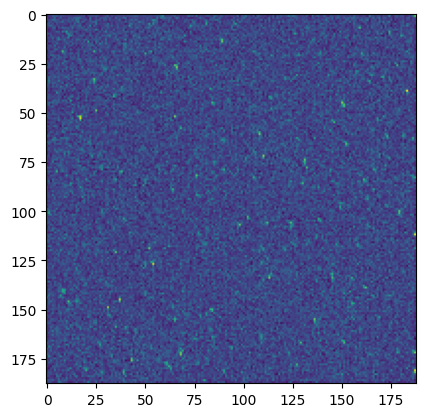

In [4]:
plt.imshow(a[...,66].max(axis=0))